# SVHN Digit Classification

This notebook explores classifying house-number digits from the [Street View House Numbers (SVHN)](http://ufldl.stanford.edu/housenumbers/) dataset. It compares several approaches:

1. A baseline MLP classifier on raw pixel features
2. Preprocessing experiments (grayscale conversion, black/white normalization)
3. Dimensionality reduction with PCA
4. An ensemble (voting) of MLPs trained on different feature subsets
5. A custom convolutional neural network (CNN) built with PyTorch

**Data requirement:** this notebook expects `train_32x32.mat` and `test_32x32.mat` (the "Format 2" cropped-digit `.mat` files from the SVHN site) to be present in the same directory as this notebook. They are not included in this repo due to size — download them from the link above.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from IPython import display

from scipy.io import loadmat
from skimage.filters import threshold_otsu
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.ensemble import VotingClassifier

## 1. Load the data

SVHN's cropped-digit format ships as MATLAB `.mat` files. Labels run 1-10, where `10` represents the digit `0`.

In [3]:
training_data = loadmat("data/train_32x32.mat")
testing_data = loadmat("data/test_32x32.mat")

X_tr_raw = training_data['X']
y_tr = training_data['y'].ravel()
X_te_raw = testing_data['X']
y_te = testing_data['y'].ravel()

print("Train:", X_tr_raw.shape, y_tr.shape)
print("Test: ", X_te_raw.shape, y_te.shape)

Train: (32, 32, 3, 73257) (73257,)
Test:  (32, 32, 3, 26032) (26032,)


A sample image, in color:

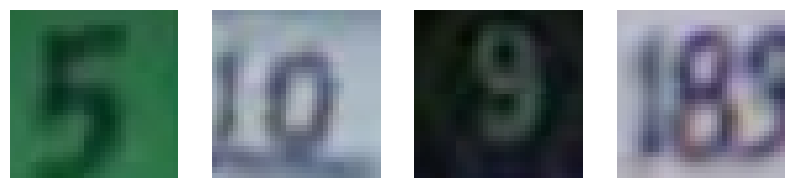

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(10, 8))
for i in range(4):
    axes[i].imshow(X_te_raw[:, :, :, i * 3])
    axes[i].axis('off')
plt.show()

## 2. Preprocessing

### Grayscale conversion

Converting to grayscale collapses the 3 color channels into a single luminance channel, cutting feature count by 3x.

In [4]:
def greyscale(image):
    """Convert an (H, W, 3, N) RGB image stack to (H, W, N) grayscale using standard luma weights."""
    weights = np.array([0.299, 0.587, 0.114])
    return np.tensordot(image, weights, axes=(2, 0)).astype(np.float64)

X_tr = greyscale(X_tr_raw)
X_te = greyscale(X_te_raw)
print("Grayscale shape:", X_tr.shape, X_te.shape)

Grayscale shape: (32, 32, 73257) (32, 32, 26032)


The same sample image after grayscale conversion:

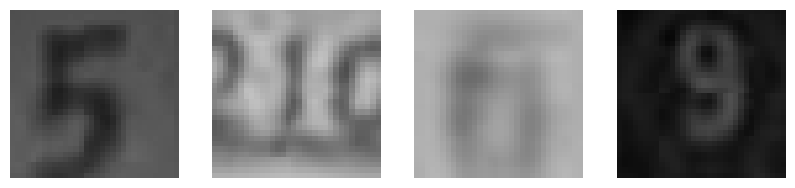

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(10, 8))
for i in range(4):
    axes[i].imshow(X_te[:, :, i*2], cmap='gray', vmin=0, vmax=255)
    axes[i].axis('off')
plt.show()

### Black/white normalization (experimental)

House numbers are photographed with either light-on-dark or dark-on-light digits. This heuristic looks at the image border to guess the background color and inverts the image so digits are consistently rendered dark-on-light.

In [5]:
def otsu_compare(X, border_width=2, min_std=10):
    """Return a copy of X where images with a mostly-black border are inverted so the
    border becomes white. Does not modify the input array.

    Samples a border_width-pixel-deep margin (wider than a single edge pixel, for a less
    noisy sample) and thresholds it via Otsu's method. If that border has very low variance
    (min_std), there's no real dark/light split to find and Otsu's threshold would just be
    splitting noise -- in that case, fall back to comparing the border's mean brightness
    against the midpoint of the pixel range (128) instead.
    """
    X = X.copy()
    num_images = X.shape[2]
    for i in range(num_images):
        if i != 0:
            continue
        top = X[:border_width, :, i].ravel()
        bottom = X[-border_width:, :, i].ravel()
        left = X[:, :border_width, i].ravel()
        right = X[:, -border_width:, i].ravel()
        border = np.concatenate([top, bottom, left, right])
        cutoff = threshold_otsu(border.astype(np.float64))
        num_white = (border > cutoff).sum()
        num_black = (border <= cutoff).sum()
        if num_black > num_white:
            X[:, :, i] = 255 - X[:, :, i]
    return X

X_trw_otsu = otsu_compare(X_tr)
X_tew_otsu = otsu_compare(X_te)

The same sample image after the black/white normalization pass:

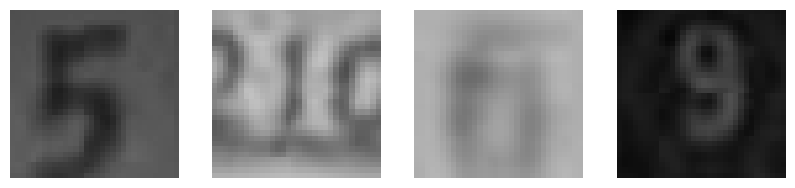

In [35]:
fig, axes = plt.subplots(1, 4, figsize=(10, 8))
for i in range(4):
    axes[i].imshow(X_tew_otsu[:, :, i*2], cmap='gray', vmin=0, vmax=255)
    axes[i].axis('off')
plt.show()

In [6]:
def mean_compare(X, border_width=1, interior_margin=8):
    """Return a copy of X where images with a lighter-than-background digit are inverted
    so the digit ends up dark-on-light. Does not modify the input array.

    Compares the mean brightness of a center interior patch (where the digit is expected to
    be) against the mean brightness of the border margin (background). These two regions
    don't overlap, so this is a clean two-region contrast rather than mixing the whole image
    (digit + background) against the border alone.
    """
    X = X.copy()
    num_images = X.shape[2]
    for i in range(num_images):
        top = X[:border_width, :, i].ravel()
        bottom = X[-border_width:, :, i].ravel()
        left = X[:, :border_width, i].ravel()
        right = X[:, -border_width:, i].ravel()
        border = np.concatenate([top, bottom, left, right])

        interior = X[interior_margin:-interior_margin, interior_margin:-interior_margin, i]

        if interior.mean() > border.mean():
            X[:, :, i] = 255 - X[:, :, i]
    return X

X_trw_mean = mean_compare(X_tr)
X_tew_mean = mean_compare(X_te)

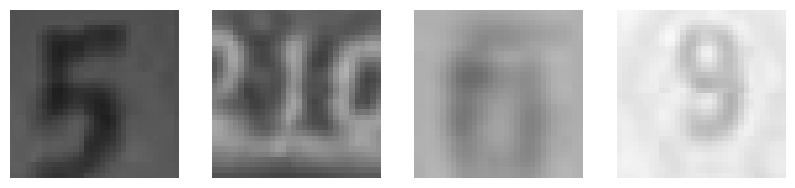

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(10, 8))
for i in range(4):
    axes[i].imshow(X_tew_mean[:, :, i*2], cmap='gray', vmin=0, vmax=255)
    axes[i].axis('off')
plt.show()

Keep a copy of the images in their original 2D shape (`N, 32, 32`) for the CNN section later — the next step flattens `X_tr`/`X_te` into 1024-length feature vectors for the MLP/PCA experiments, which a `Conv2d` layer can't consume directly.

In [7]:
X_tr_img = np.transpose(X_tr, (2, 0, 1)).copy()  # (N, 32, 32), still in [0, 255]
X_te_img = np.transpose(X_te, (2, 0, 1)).copy()
X_trw_otsu_img = np.transpose(X_trw_otsu, (2, 0, 1)).copy()
X_tew_otsu_img = np.transpose(X_tew_otsu, (2, 0, 1)).copy()
X_trw_mean_img = np.transpose(X_trw_mean, (2, 0, 1)).copy()
X_tew_mean_img = np.transpose(X_tew_mean, (2, 0, 1)).copy()

## 3. Baseline MLP

### Flatten and normalize

Reshape each 32x32 image into a 1024-length feature vector and scale pixel values to `[0, 1]`.

In [38]:
print("Before:", X_tr.shape, X_te.shape, y_tr.shape, y_te.shape)

X_tr = (X_tr.reshape(1024, X_tr.shape[2]) / 255.0).T
X_te = (X_te.reshape(1024, X_te.shape[2]) / 255.0).T
X_trw_otsu = (X_trw_otsu.reshape(1024, X_trw_otsu.shape[2]) / 255.0).T
X_tew_otsu = (X_tew_otsu.reshape(1024, X_tew_otsu.shape[2]) / 255.0).T
X_trw_mean = (X_trw_mean.reshape(1024, X_trw_mean.shape[2]) / 255.0).T
X_tew_mean = (X_tew_mean.reshape(1024, X_tew_mean.shape[2]) / 255.0).T

print("After: ", X_tr.shape, X_te.shape, y_tr.shape, y_te.shape)

Before: (32, 32, 73257) (32, 32, 26032) (73257,) (26032,)
After:  (73257, 1024) (26032, 1024) (73257,) (26032,)


In [14]:
def train_mlp(X_tr, y_tr, X_te, y_te, title, hidden_layer_sizes, n_epochs=100, patience=10, verbose=False):
    mlp = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation='relu',
        solver='adam',
        batch_size=256,
        random_state=123,
    )

    classes = np.unique(y_tr)
    train_accs, test_accs = [], []
    best_test_acc = 0
    epochs_no_improve = 0

    for epoch in range(n_epochs):
        if epoch == 0:
            mlp.partial_fit(X_tr, y_tr, classes=classes)
        else:
            mlp.partial_fit(X_tr, y_tr)
        train_acc = mlp.score(X_tr, y_tr)
        test_acc = mlp.score(X_te, y_te)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        if verbose:
            print(f"Epoch {epoch+1}: train_acc={train_acc:.4f}, test_acc={test_acc:.4f}")

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
                break

    plt.plot(range(1, len(train_accs) + 1), train_accs, label='Train Accuracy')
    plt.plot(range(1, len(test_accs) + 1), test_accs, label='Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f"MLP: {title}")
    plt.show()
    return best_test_acc

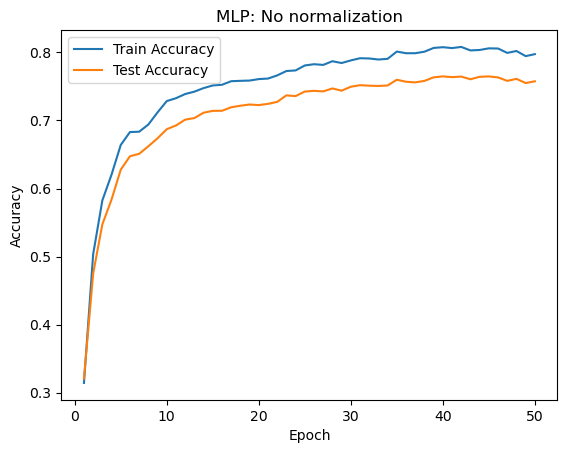

Best test accuracy: 0.7648279041180086


In [15]:
acc = train_mlp(X_tr, y_tr, X_te, y_te, "No normalization", (128, 64, 32))
print("Best test accuracy:", acc)

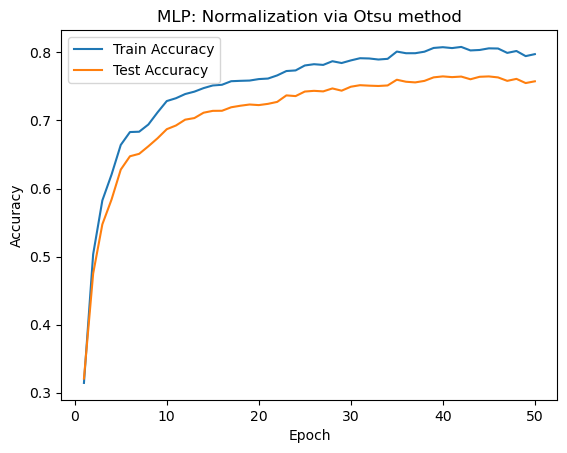

Best test accuracy: 0.7648279041180086


In [16]:
acc = train_mlp(X_trw_otsu, y_tr, X_tew_otsu, y_te, "Normalization via Otsu method", (128, 64, 32))
print("Best test accuracy:", acc)

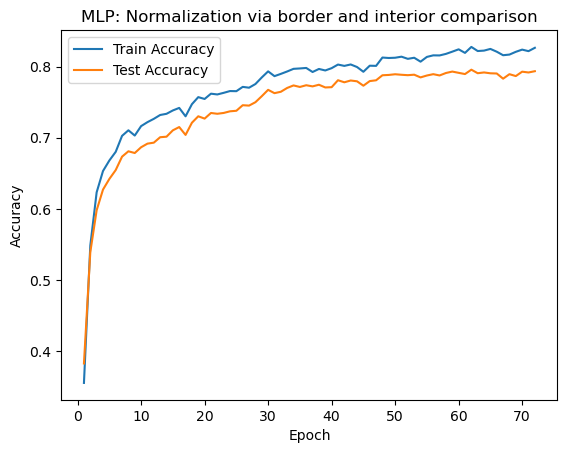

Best test accuracy: 0.7956745543945912


In [17]:
acc = train_mlp(X_trw_mean, y_tr, X_tew_mean, y_te, "Normalization via border and interior comparison", (128, 64, 32))
print("Best test accuracy:", acc)

### Comparing hidden-layer architectures

Three architectures: a deep-and-narrow net, a shallow-and-wide net, and a single wide layer.

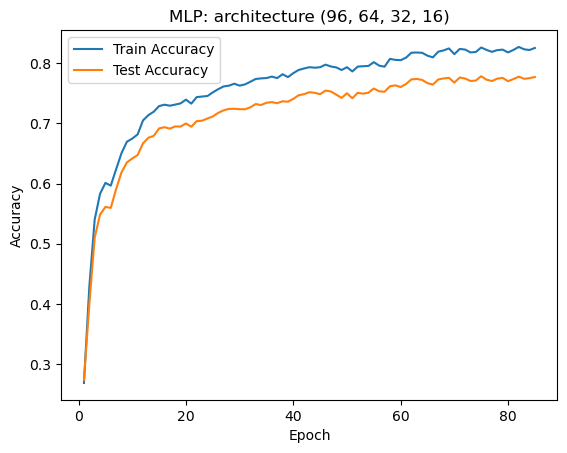

Best test accuracy: 0.7783497234173326


In [18]:
acc = train_mlp(X_tr, y_tr, X_te, y_te, "architecture (96, 64, 32, 16)", (96, 64, 32, 16))
print("Best test accuracy:", acc)

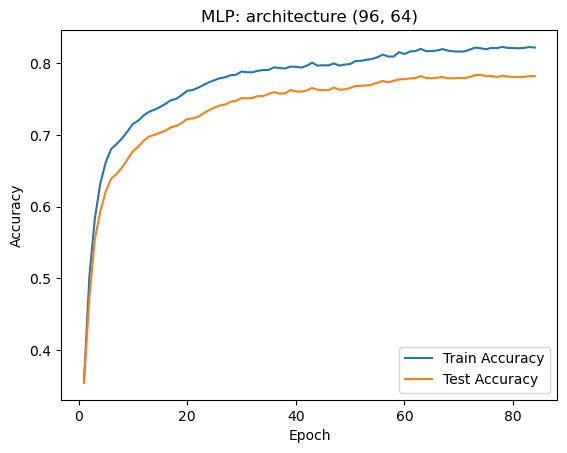

Best test accuracy: 0.7836508912108174


In [19]:
acc = train_mlp(X_tr, y_tr, X_te, y_te, "architecture (96, 64)", (96, 64))
print("Best test accuracy:", acc)

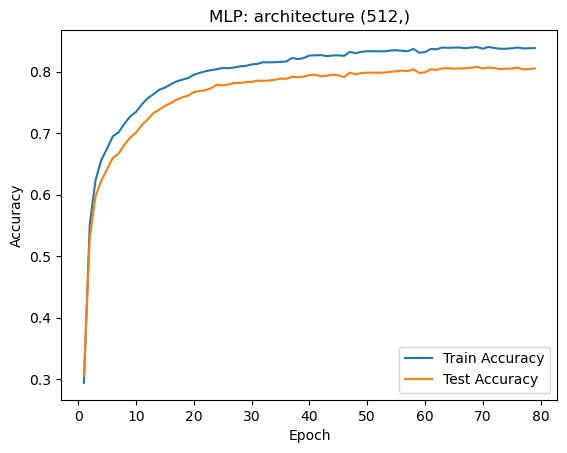

Best test accuracy: 0.8078518746158574


In [20]:
acc = train_mlp(X_tr, y_tr, X_te, y_te, "architecture (512,)", (512,))
print("Best test accuracy:", acc)

A deeper, wider two-layer net (`1024, 512`) on the same subset:

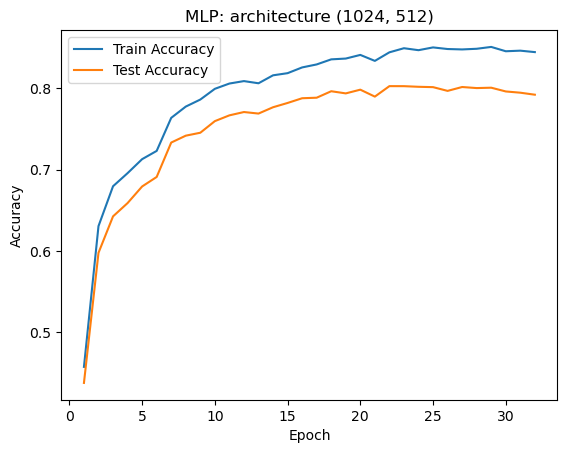

Best test accuracy: 0.8025891210817455


In [21]:
acc = train_mlp(X_tr, y_tr, X_te, y_te, "architecture (1024, 512)", (1024, 512))
print("Best test accuracy:", acc)

## 4. Dimensionality reduction with PCA

Raw 1024-pixel features are highly redundant. PCA lets us keep most of the variance with far fewer dimensions.

In [39]:
pca = PCA(n_components=0.98)  # keep components explaining 98% of variance
X_tr_pca = pca.fit_transform(X_tr)
X_te_pca = pca.transform(X_te)

print("Original shape:", X_tr.shape, "->", "Reduced shape:", X_tr_pca.shape)
print("Original shape:", X_te.shape, "->", "Reduced shape:", X_te_pca.shape)

Original shape: (73257, 1024) -> Reduced shape: (73257, 86)
Original shape: (26032, 1024) -> Reduced shape: (26032, 86)


An MLP trained directly on the PCA-reduced features:

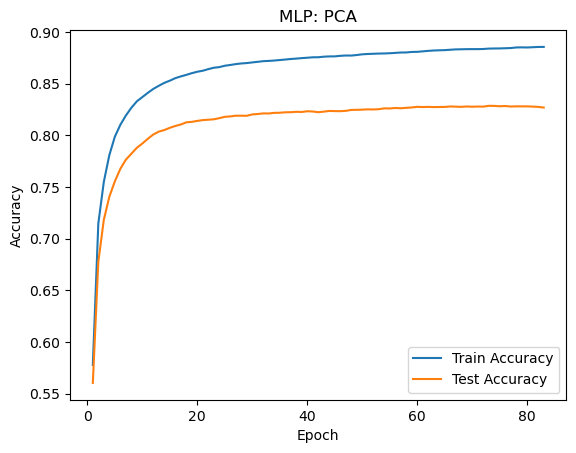

Best test accuracy: 0.828518746158574


In [23]:
acc = train_mlp(X_tr_pca, y_tr, X_te_pca, y_te, "PCA", (64, 32))
print("Best test accuracy:", acc)

### Sweeping the PCA variance target

How does test error change as we vary how much variance PCA is allowed to discard?

In [40]:
%%capture
pca_values = [0.90, 0.95, 0.98, 0.99]
pca_accs = []

for pca_value in pca_values:
    pca = PCA(n_components=pca_value)
    X_tr_pca = pca.fit_transform(X_tr)
    X_te_pca = pca.transform(X_te)
    pca_acc = train_mlp(X_tr_pca, y_tr, X_te_pca, y_te, "", (64, 32))
    pca_accs.append(pca_acc)

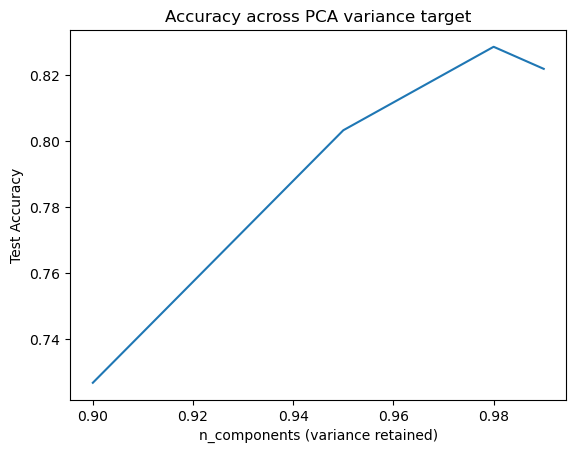

In [41]:
plt.plot(pca_values, pca_accs)
plt.xlabel('n_components (variance retained)')
plt.ylabel('Test Accuracy')
plt.title('Accuracy across PCA variance target')
plt.show()

## 5. Ensembling MLPs on feature subsets

Each sub-model sees only a slice of the PCA-reduced features; a soft-voting ensemble combines their predictions. First with 2 members splitting the features in half, then with 3 members using overlapping slices.

In [ ]:
select_first_half = FunctionTransformer(lambda X: X[:, :63], validate=False)
select_second_half = FunctionTransformer(lambda X: X[:, 63:], validate=False)

mlp1 = Pipeline([
    ('feature_selector', select_first_half),
    ('mlp', MLPClassifier(hidden_layer_sizes=(50,), activation='relu', learning_rate_init=0.01,
                           batch_size=256, random_state=123, solver='sgd', max_iter=500, alpha=0.01))
])
mlp2 = Pipeline([
    ('feature_selector', select_second_half),
    ('mlp', MLPClassifier(hidden_layer_sizes=(50,), activation='relu', learning_rate_init=0.01,
                           batch_size=256, random_state=123, solver='sgd', max_iter=500, alpha=0.01))
])

voting_clf_2 = VotingClassifier(estimators=[('mlp1', mlp1), ('mlp2', mlp2)], voting='soft')
voting_clf_2.fit(Xtr_pca, y_tr)
error_2way = 1 - voting_clf_2.score(Xtr_pca[:num], y_tr[:num])
print("2-way ensemble train error:", error_2way)

select_1 = FunctionTransformer(lambda X: X[:, 42:], validate=False)
select_2 = FunctionTransformer(lambda X: X[:, 42:84], validate=False)
select_3 = FunctionTransformer(lambda X: X[:, 84:], validate=False)

mlp1 = Pipeline([
    ('feature_selector', select_1),
    ('mlp', MLPClassifier(hidden_layer_sizes=(50,), activation='relu', learning_rate_init=0.01,
                           batch_size=256, random_state=123, solver='sgd', max_iter=500, alpha=0.01))
])
mlp2 = Pipeline([
    ('feature_selector', select_2),
    ('mlp', MLPClassifier(hidden_layer_sizes=(50,), activation='relu', learning_rate_init=0.01,
                           batch_size=256, random_state=123, solver='sgd', max_iter=500, alpha=0.01))
])
mlp3 = Pipeline([
    ('feature_selector', select_3),
    ('mlp', MLPClassifier(hidden_layer_sizes=(50,), activation='relu', learning_rate_init=0.01,
                           batch_size=256, random_state=123, solver='sgd', max_iter=500, alpha=0.01))
])

voting_clf_3 = VotingClassifier(estimators=[('mlp1', mlp1), ('mlp2', mlp2), ('mlp3', mlp3)], voting='soft')
voting_clf_3.fit(Xtr_pca, y_tr)
error_3way = 1 - voting_clf_3.score(Xtr_pca[:num], y_tr[:num])
print("3-way ensemble train error:", error_3way)

A single MLP trained on the full PCA feature set, for comparison against the ensembles above:

In [ ]:
mlp_single = MLPClassifier(hidden_layer_sizes=(50,), activation='relu', learning_rate_init=0.01,
                            batch_size=256, random_state=123, solver='sgd', max_iter=10, alpha=0.01)
mlp_single.fit(Xtr_pca, y_tr)
error_single = 1 - mlp_single.score(Xtr_pca[:num], y_tr[:num])
print("Single-MLP train error:", error_single)

## 6. Convolutional neural network

A minimal configurable CNN built on top of `torch.nn.Module`, trained directly on the (non-flattened) grayscale images. Based on the approach in `pyimagesearch.com/2021/07/19/pytorch-training-your-first-convolutional-neural-network-cnn`.

`draw_model` is a helper that trains a model across a list of iteration counts and plots train/test accuracy alongside a confusion matrix.

In [8]:
def draw_model(model, X_tr, y_tr, X_te, y_te, iterations, **features):
    """Train `model` at each iteration count in `iterations`, plotting accuracy curves
    and a confusion matrix for the final fit.

    Example: draw_model(MLPClassifier, X_tr, y_tr, X_te, y_te, [10, 100, 1000],
                         hidden_layer_sizes=(50,), activation='relu', learning_rate_init=0.01,
                         batch_size=256, random_state=123, solver='sgd')
    """
    accs_tr = []
    accs_te = []
    for iters in iterations:
        learner = model(**features, max_iter=iters)
        learner.fit(X_tr, y_tr)
        y_tr_hat = learner.predict(X_tr)
        y_te_hat = learner.predict(X_te)
        accs_tr.append((y_tr_hat == y_tr).mean())
        accs_te.append((y_te_hat == y_te).mean())

    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    ConfusionMatrixDisplay.from_estimator(learner, X_tr, y_tr, ax=axs[1])
    axs[0].plot(iterations, accs_tr, 'b--', label='Train Accuracy')
    axs[0].plot(iterations, accs_te, 'r--', label='Test Accuracy')
    axs[0].legend()
    axs[0].set_xlabel('Iterations')
    axs[0].set_ylabel('Accuracy')
    plt.tight_layout()
    plt.show()

In [20]:
def get_list_or_num_param_val(param, index):
    """Allow a hyperparameter to be given either as a single value (used for every layer)
    or a per-layer list/tuple."""
    if type(param) not in (list, tuple):
        return param
    return param[index] if len(param) > index else param[0]


class SimpleConvNet(torch.nn.Module):
    def __init__(self, numChannels=1, classes=10, channel_sizes=(32, 64), kernel_sizes=((3, 3),),
                 strides=(1,), conv_paddings=(1,), pool_kernels=((2, 2),), pool_strides=(2,),
                 pool_paddings=(0,), fully_connected_features=128, device=None, **hyperparameters):
        super().__init__()
        if device is None:
            device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.device = torch.device(device)

        # we store our operations in lists: convolutional layer -> pool -> ...
        self.conv_ = list()
        self.pool_ = list()
        for i in range(len(channel_sizes)):
            c = torch.nn.Conv2d(in_channels=numChannels if i == 0 else channel_sizes[i - 1],
                                 out_channels=channel_sizes[i],
                                 kernel_size=get_list_or_num_param_val(kernel_sizes, i),
                                 stride=get_list_or_num_param_val(strides, i),
                                 padding=get_list_or_num_param_val(conv_paddings, i))
            p = torch.nn.MaxPool2d(kernel_size=get_list_or_num_param_val(pool_kernels, i),
                                    stride=get_list_or_num_param_val(pool_strides, i),
                                    padding=get_list_or_num_param_val(pool_paddings, i))
            self.add_convolution(c, p)

        # first fully connected layer - LazyLinear infers correct in_features on first pass
        self.fc1 = torch.nn.LazyLinear(out_features=fully_connected_features)
        self.fc2 = torch.nn.Linear(in_features=fully_connected_features, out_features=classes)
        self.logSoftmax = torch.nn.LogSoftmax(dim=1)
        self.set_hyperparameters(**hyperparameters)
        self.to(self.device)

    def add_convolution(self, conv, pool):
        self.conv_.append(conv)
        self.pool_.append(pool)
        setattr(self, f"c{len(self.pool_)}", conv)
        setattr(self, f"p{len(self.pool_)}", pool)

    def set_hyperparameters(self, learning_rate_init=1e-3, batch_size=64, max_iter=100,
                             momentum=0.9, alpha=.001, activation='relu', **more):
        self.lr = learning_rate_init
        self.batch_size = batch_size
        self.epochs = max_iter
        self.momentum = momentum
        self.alpha = alpha
        # reference: machinelearningmastery.com/activation-functions-in-pytorch/
        if activation == 'relu':
            self.activation_ = torch.nn.ReLU()
        elif activation == 'logistic':
            self.activation_ = torch.nn.Sigmoid()
        elif activation == 'tanh':
            self.activation_ = torch.nn.Tanh()
        elif activation == 'leakyrelu':
            self.activation_ = torch.nn.LeakyReLU()
        else:
            # any other activation function. See: https://pytorch.org/docs/stable/nn.html
            self.activation_ = activation
        if more:
            print("WARNING - unrecognized CNN hyperparameters:", ",".join(more.keys()))
        return self

    def forward(self, X):
        """Compute NN forward pass and output class probabilities (as tensor)."""
        for conv, pool in zip(self.conv_, self.pool_):
            X = pool(self.activation_(conv(X)))
        X_flat = torch.flatten(X, 1)
        X = self.activation_(self.fc1(X_flat))
        X = self.fc2(X)
        return self.logSoftmax(X)

    def predict_prob(self, X, batch_size=512):
        self.eval()
        X = torch.Tensor(X).unsqueeze(1)
        outputs = []
        with torch.no_grad():
            for i in range(0, X.shape[0], batch_size):
                batch = X[i:i + batch_size].to(self.device)
                outputs.append(self.forward(batch).cpu())
        return torch.cat(outputs, dim=0).numpy()

    def predict(self, X, batch_size=512):
        results = self.predict_prob(X, batch_size=batch_size)
        return np.argmax(results, axis=1)

    def fit(self, X, y, optimizer='adam', X_te=None, y_te=None, early_stopping=False, 
            patience=10, restore_best_weights=True):
        if early_stopping and (X_te is None or y_te is None):
            raise ValueError("early_stopping=True requires X_val and y_val to monitor")

        self.classes_ = np.unique(y)
        self.train_acc_, self.test_acc_ = list(), list()
        lossFn = torch.nn.NLLLoss()
        X = torch.Tensor(X)
        y = torch.Tensor(y).long()
        train_data = torch.utils.data.TensorDataset(X.unsqueeze(1), y)
        trainDataLoader = torch.utils.data.DataLoader(
            train_data, shuffle=True, batch_size=self.batch_size,
            pin_memory=(self.device.type == 'cuda')
        )
        if optimizer == 'adam':
            optimizer = torch.optim.Adam(self.parameters(), lr=self.lr, weight_decay=self.alpha)

        best_test_acc = 0
        best_state = None
        epochs_no_improve = 0

        for epoch in range(self.epochs):
            self.train()
            for (x, y_batch) in trainDataLoader:
                x = x.to(self.device, non_blocking=True)
                y_batch = y_batch.to(self.device, non_blocking=True)
                optimizer.zero_grad()
                pred = self(x)
                loss = lossFn(pred, y_batch)
                loss.backward()
                optimizer.step()

            if X_te is not None and y_te is not None:
                train_pred = self.predict(X.numpy())
                test_pred = self.predict(X_te)
                test_acc = (test_pred == y_te).mean()
                self.train_acc_.append((train_pred == y.numpy()).mean())
                self.test_acc_.append(test_acc)
                
                if early_stopping:
                    if test_acc > best_test_acc:
                        best_test_acc = test_acc
                        epochs_no_improve = 0
                        if restore_best_weights:
                            best_state = {k: v.clone() for k, v in self.state_dict().items()}
                    else:
                        epochs_no_improve += 1
                        if epochs_no_improve >= patience:
                            break

        if early_stopping and restore_best_weights and best_state is not None:
            self.load_state_dict(best_state)

In [21]:
def train_cnn(X_tr, y_tr, X_te, y_te, title, n_epochs=100, patience=10,
              batch_size=512, device=None, **cnn_kwargs):
    cnn = SimpleConvNet(device=device, max_iter=n_epochs, batch_size=batch_size, **cnn_kwargs)
    cnn.fit(
        X_tr / 255.0, y_tr - 1,
        X_te=X_te / 255.0, y_te=y_te - 1,
        early_stopping=True, patience=patience
    )

    best_test_acc = max(cnn.test_acc_)

    epochs_range = range(1, len(cnn.train_acc_) + 1)
    plt.plot(epochs_range, cnn.train_acc_, label='Train Accuracy')
    plt.plot(epochs_range, cnn.test_acc_, label='Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f"CNN: {title}")
    plt.show()

    return best_test_acc

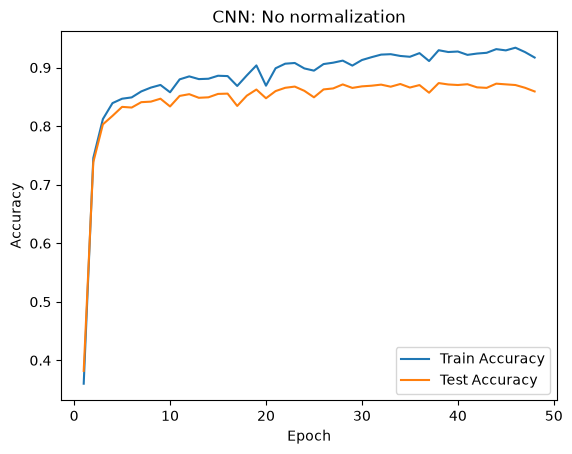

Best test accuracy: 0.8735786724031961


In [31]:
best_acc = train_cnn(X_tr_img, y_tr, X_te_img, y_te, title="No normalization")
print(f"Best test accuracy: {best_acc}")

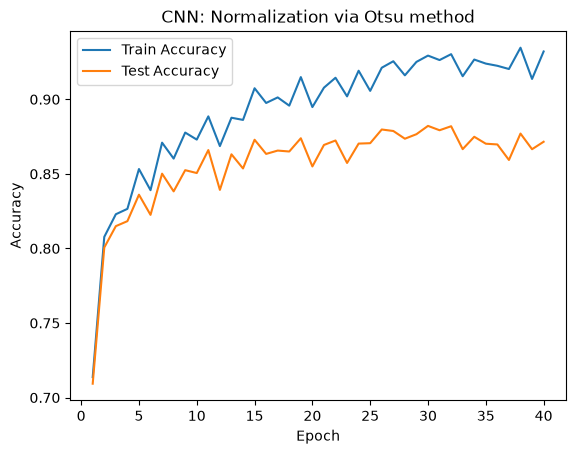

Best test accuracy: 0.8821834665027658


In [23]:
best_acc = train_cnn(X_trw_otsu_img, y_tr, X_tew_otsu_img, y_te, title="Normalization via Otsu method")
print(f"Best test accuracy: {best_acc}")

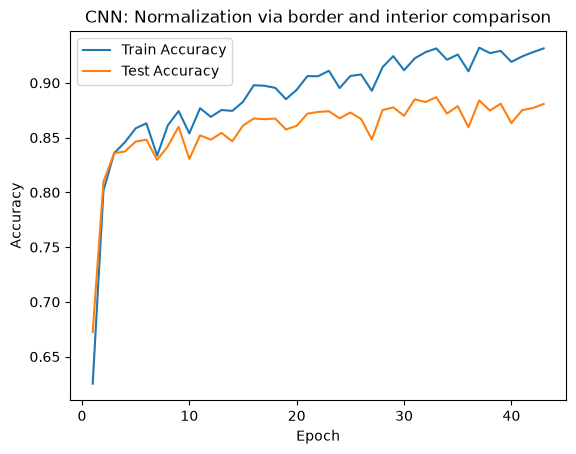

Best test accuracy: 0.8869468346650277


In [24]:
best_acc = train_cnn(X_trw_mean_img, y_tr, X_tew_mean_img, y_te, title="Normalization via border and interior comparison")
print(f"Best test accuracy: {best_acc}")

Train the CNN directly, and again wrapped in a `Pipeline` with a rescaling step. This uses `X_tr_img`/`X_te_img` — the un-flattened image copies saved earlier — since a CNN needs 2D spatial structure, not flat feature vectors.

**Note:** `draw_model` (above) expects a model *class* it can instantiate per iteration count, the way `MLPClassifier` is used elsewhere in this notebook. `CNN_learner` here is an already-fitted `Pipeline` instance, so it isn't a compatible input to `draw_model` — calling `draw_model(CNN_learner, ...)` would raise `TypeError: 'Pipeline' object is not callable`. Instead, the fitted CNN is evaluated directly below.

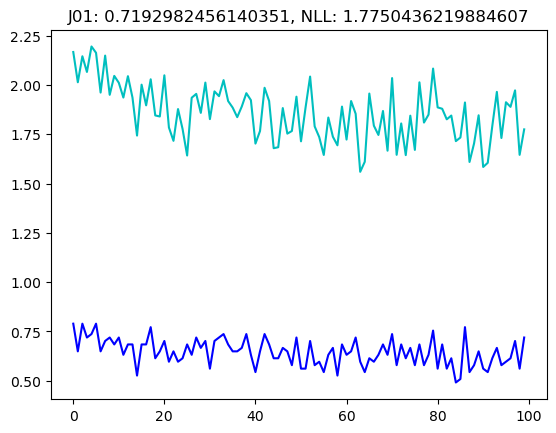

CNN train accuracy: 0.8096
CNN test accuracy:  0.7628


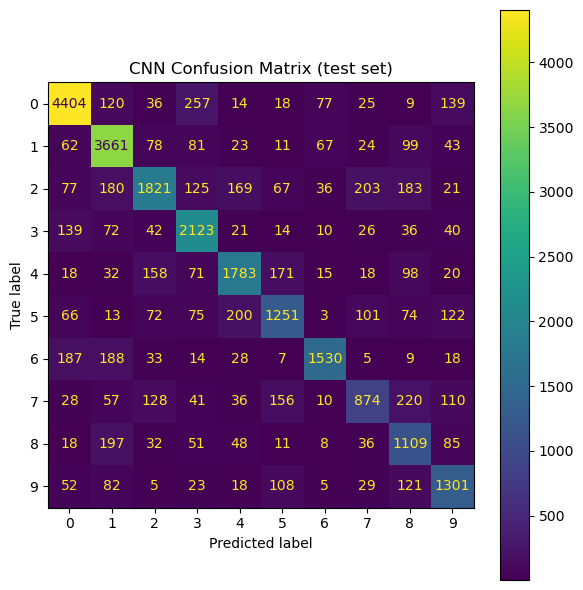

In [44]:
# we subtract 1 from the labels since SVHN labels run 1-10 but the model expects 0-9
c1 = SimpleConvNet(channel_sizes=(78, 25))
c1.set_hyperparameters(max_iter=100, batch_size=200)
c1.fit(X_tr_img, y_tr - 1, plot=True)

greyscale_scaler = FunctionTransformer(lambda X: X / 255.0, validate=False)
CNN_learner = Pipeline([
    ('scaler', greyscale_scaler),
    ('cnn', SimpleConvNet())
])
CNN_learner._model_name = "CNN Learner"
CNN_learner.fit(X_tr_img, y_tr - 1)

train_acc = (CNN_learner.named_steps['cnn'].predict(X_tr_img / 255.0) == (y_tr - 1)).mean()
test_acc = (CNN_learner.named_steps['cnn'].predict(X_te_img / 255.0) == (y_te - 1)).mean()
print(f"CNN train accuracy: {train_acc:.4f}")
print(f"CNN test accuracy:  {test_acc:.4f}")

fig, ax = plt.subplots(figsize=(6, 6))
y_te_pred = CNN_learner.named_steps['cnn'].predict(X_te_img / 255.0)
ConfusionMatrixDisplay.from_predictions(y_te - 1, y_te_pred, ax=ax)
plt.title("CNN Confusion Matrix (test set)")
plt.tight_layout()
plt.show()

## Appendix
### Preprocessing: Optimal Border Width and Interior Margin for Normalization via Border + Interior Comparison

In [ ]:
training_data = loadmat("data/train_32x32.mat")
testing_data = loadmat("data/test_32x32.mat")
X_tr_raw = training_data['X']
X_te_raw = testing_data['X']
X_tr = greyscale(X_tr_raw)
X_te = greyscale(X_te_raw)

In [ ]:
%%capture
accs = {}
for border, interior in [(1, 1), (1, 2), (1, 4), (1, 8), (1, 12), (2, 2), (2, 4), (2, 8), (2, 12)]:
    X_tr_temp = mean_compare(X_tr, border, interior)
    X_te_temp = mean_compare(X_te, border, interior)
    X_tr_temp = (X_tr_temp.reshape(1024, X_tr_temp.shape[2]) / 255.0).T
    X_te_temp = (X_te_temp.reshape(1024, X_te_temp.shape[2]) / 255.0).T
    acc = train_mlp(X_tr_temp, y_tr, X_te_temp, y_te, "", (128, 64, 32))
    accs[(border, interior)] = acc
print(accs)
plt.close('all')

In [30]:
accs

{(1, 1): 0.788759987707437,
 (1, 2): 0.7858789182544561,
 (1, 4): 0.7938306699446834,
 (1, 8): 0.7956745543945912,
 (1, 12): 0.7917562999385371,
 (2, 2): 0.7554548248309773,
 (2, 4): 0.7869161032575291,
 (2, 8): 0.7906038721573448,
 (2, 12): 0.7760064535955746}

### CNN: alpha (Weight Decay)

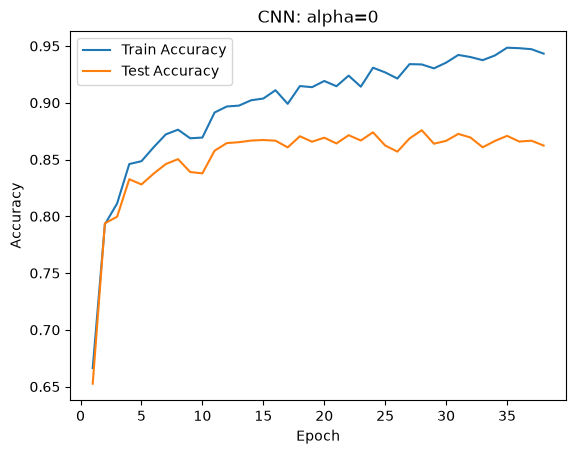

Best test accuracy: 0.8758066994468346


In [27]:
best_acc = train_cnn(X_tr_img, y_tr, X_te_img, y_te, title="alpha=0", alpha=0)
print(f"Best test accuracy: {best_acc}")

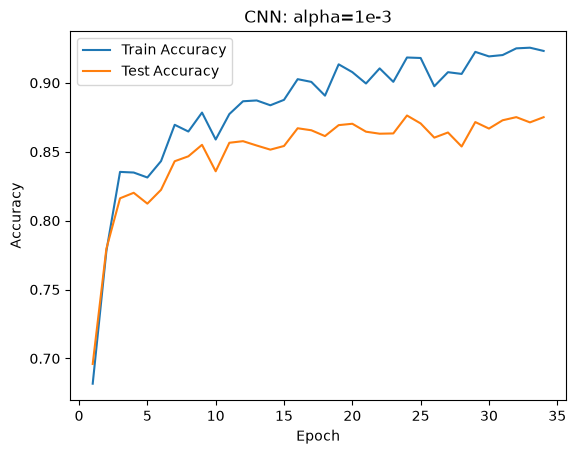

Best test accuracy: 0.8763060848186847


In [28]:
best_acc = train_cnn(X_tr_img, y_tr, X_te_img, y_te, title="alpha=1e-3", alpha=1e-3)
print(f"Best test accuracy: {best_acc}")

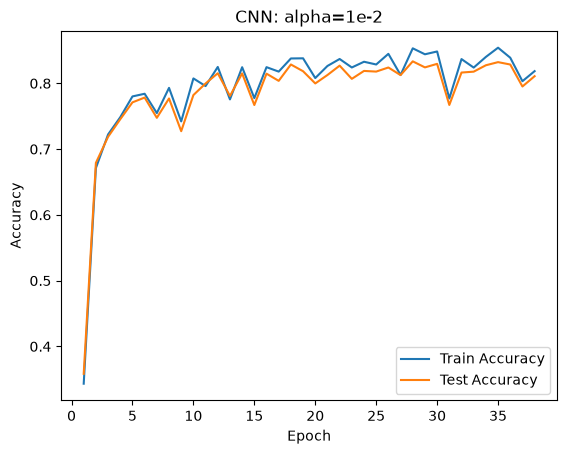

Best test accuracy: 0.8333973570989551


In [30]:
best_acc = train_cnn(X_tr_img, y_tr, X_te_img, y_te, title="alpha=1e-2", alpha=1e-2)
print(f"Best test accuracy: {best_acc}")